# 🟠 Chapter 7: Working with Text Data
**Referensi:** *Introduction to Machine Learning with Python* (Andreas C. Müller & Sarah Guido)
---
> **Author:** Dhafi Dzakwan Pratama | 101032300213
> **Topik:** Bag-of-Words, TF-IDF, n-Grams, dan Topic Modeling (LDA)
---
## 1. Representasi Data Teks (Bag-of-Words)
Model *Machine Learning* tidak bisa membaca teks secara langsung. Kita harus mengubah teks menjadi representasi numerik. Metode paling dasar adalah **Bag-of-Words**, yang menghitung frekuensi kemunculan setiap kata dalam sebuah dokumen, mengabaikan urutan dan struktur kalimatnya.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

%matplotlib inline

# Contoh dataset teks sederhana
bards_words =["The fool doth think he is wise,",
              "but the wise man knows himself to be a fool"]

vect = CountVectorizer()
vect.fit(bards_words)

print("Ukuran Kosakata (Vocabulary size):", len(vect.vocabulary_))
print("Isi Kosakata:\n", vect.vocabulary_)

# Mengubah teks menjadi representasi vektor numerik
bag_of_words = vect.transform(bards_words)
print("\nBentuk Bag-of-Words:", bag_of_words.shape)
print("Representasi Array:\n", bag_of_words.toarray())

Ukuran Kosakata (Vocabulary size): 13
Isi Kosakata:
 {'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}

Bentuk Bag-of-Words: (2, 13)
Representasi Array:
 [[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


## 2. Term Frequency-Inverse Document Frequency (TF-IDF)
Kata-kata yang terlalu sering muncul di semua dokumen (seperti "the", "is", "a") tidak memiliki nilai informatif yang tinggi. **TF-IDF** memberikan bobot tinggi pada kata yang sering muncul dalam *satu* dokumen tertentu, tetapi jarang muncul di dokumen *lainnya*.

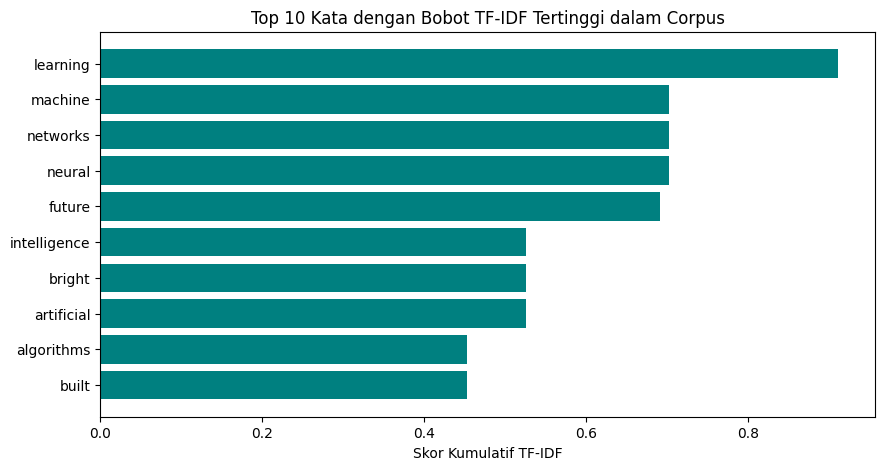

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Kumpulan kalimat (corpus) tiruan
corpus = [
    "machine learning is fascinating and machine learning is the future",
    "the future of artificial intelligence is bright",
    "deep learning algorithms are built on neural networks",
    "neural networks can learn complex patterns from data"
]

tfidf_vect = TfidfVectorizer(stop_words='english') # Membuang kata hubung (stopwords)
tfidf_matrix = tfidf_vect.fit_transform(corpus)

# Visualisasi kata dengan bobot TF-IDF tertinggi
features = tfidf_vect.get_feature_names_out()
tfidf_scores = np.asarray(tfidf_matrix.sum(axis=0)).ravel()

# Mengurutkan skor dari yang terkecil ke terbesar untuk divisualisasikan
sorted_indices = np.argsort(tfidf_scores)
top_features = features[sorted_indices[-10:]]
top_scores = tfidf_scores[sorted_indices[-10:]]

plt.figure(figsize=(10, 5))
plt.barh(top_features, top_scores, color='teal')
plt.title("Top 10 Kata dengan Bobot TF-IDF Tertinggi dalam Corpus")
plt.xlabel("Skor Kumulatif TF-IDF")
plt.show();

## 3. Topic Modeling dengan Latent Dirichlet Allocation (LDA)
Seringkali kita memiliki banyak teks tanpa label dan ingin mengelompokkannya berdasarkan topik pembicaraan. **LDA** adalah algoritma unsupervised yang mencoba menemukan "topik tersembunyi" di dalam sekumpulan dokumen.

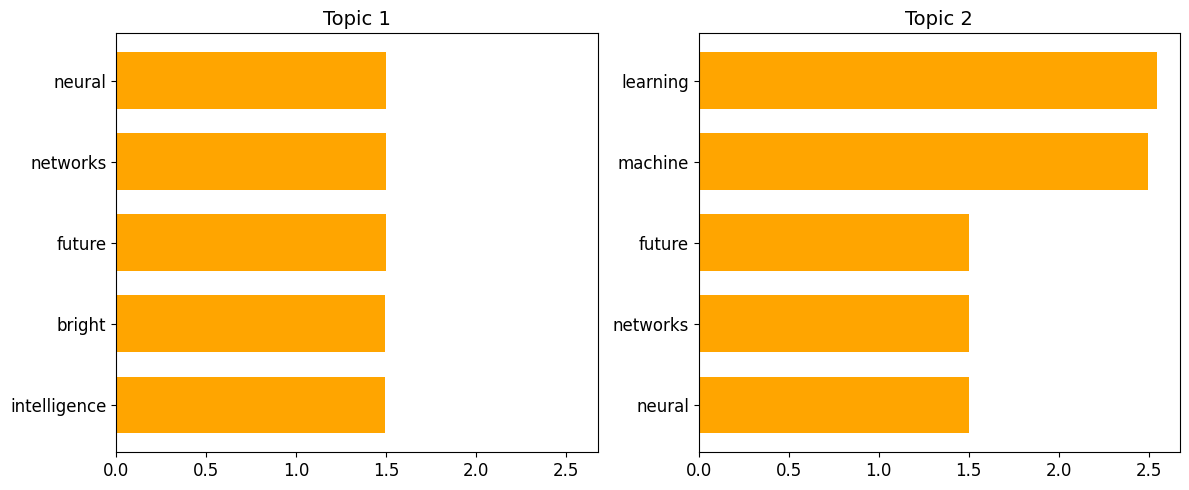

In [3]:
from sklearn.decomposition import LatentDirichletAllocation

# Kita gunakan matriks kata dari corpus sebelumnya (tanpa TF-IDF, cukup frekuensi kata untuk LDA)
vect_lda = CountVectorizer(stop_words='english')
X_lda = vect_lda.fit_transform(corpus)

# Mencari 2 topik (n_components=2)
lda = LatentDirichletAllocation(n_components=2, learning_method="batch", random_state=0)
document_topics = lda.fit_transform(X_lda)

# Visualisasi Top Kata untuk setiap Topik
topics = lda.components_
feature_names = vect_lda.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
for topic_idx, topic in enumerate(topics):
    top_features_ind = topic.argsort()[:-6:-1] # Ambil 5 kata teratas
    top_features = [feature_names[i] for i in top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    ax.barh(top_features, weights, height=0.7, color='orange')
    ax.set_title(f'Topic {topic_idx + 1}', fontdict={'fontsize': 14})
    ax.invert_yaxis()
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show();